In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import sys
import re
import os
import glob
from matplotlib import rcParams
import random
from matplotlib.colors import LogNorm

%matplotlib inline


rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

In [11]:
path = "/data/elena/data/p_340"
filename = os.path.join(path, "WCTE_merged_production_R1846.root")  #already processed data

with uproot.open(filename) as file:
    for key in file.keys():
        print(f"Tree: {key}")

Tree: WCTEReadoutWindows;10334
Tree: WCTEReadoutWindows;10333
Tree: vme_analysis_scalar_results;1
Tree: vme_analysis_run_info;1
Tree: DataQualityMetrics;1
Tree: Configuration;1


In [23]:
window_branches = [
    "window_data_quality_mask",
    "vme_evt_quality_bitmask",
    "vme_digi_issues_bitmask",

    "T5_HasValidHit",
    "T5_HasMultipleScintillatorsHit",
    "T5_HasOutOfTimeWindow",
    "T5_HasInTimeWindow",
    "T5_particle_nr",

    "vme_act_eveto",
    "vme_act_tagger",

    "vme_tof_corr",

    "window_time",
    "start_counter",
    "spill_counter",
    "event_number",
    "readout_number",
    "hit_mpmt_slot_ids",
    "hit_pmt_position_ids",
    "hit_pmt_charges",
    "hit_pmt_calibrated_times"
]

scalar_branches = [
    "act_eveto_cut",
    "act_tagger_cut",
    
    "tof_mean_pion",

    "n_pions",
    "momentum_mean_pion"  
]

N = 100000000


with uproot.open(filename) as file:
    tree_windows = file["WCTEReadoutWindows"]
    tree_scalars = file["vme_analysis_scalar_results"]
    

    arrays_windows = tree_windows.arrays(
        window_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )
    

    arrays_scalars = tree_scalars.arrays(
        scalar_branches,
        entry_start=0,
        entry_stop=N,
        library="ak"
    )



print("--- WCTEReadoutWindows Data ---")

for field in arrays_windows.fields:
    print(f"  - {field}")

print("\n--- vme_analysis_scalar_results Data ---")
for field in arrays_scalars.fields:
    print(f"  - {field}")


print(f"Loaded events: {len(arrays_windows.window_time)}")

--- WCTEReadoutWindows Data ---
  - window_data_quality_mask
  - vme_evt_quality_bitmask
  - vme_digi_issues_bitmask
  - T5_HasValidHit
  - T5_HasMultipleScintillatorsHit
  - T5_HasOutOfTimeWindow
  - T5_HasInTimeWindow
  - T5_particle_nr
  - vme_act_eveto
  - vme_act_tagger
  - vme_tof_corr
  - window_time
  - start_counter
  - spill_counter
  - event_number
  - readout_number
  - hit_mpmt_slot_ids
  - hit_pmt_position_ids
  - hit_pmt_charges
  - hit_pmt_calibrated_times

--- vme_analysis_scalar_results Data ---
  - act_eveto_cut
  - act_tagger_cut
  - tof_mean_pion
  - n_pions
  - momentum_mean_pion
Loaded events: 1239982


In [24]:
#GOOD EVENTS

cond_data_quality = arrays_windows["window_data_quality_mask"] == 0
cond_evt_quality  = arrays_windows["vme_evt_quality_bitmask"] == 0
cond_digi_issues  = arrays_windows["vme_digi_issues_bitmask"] == 0

#T5
cond_valid_hit    = arrays_windows["T5_HasValidHit"] == True
cond_mult_scint   = arrays_windows["T5_HasMultipleScintillatorsHit"] == False
cond_out_of_time  = arrays_windows["T5_HasOutOfTimeWindow"] == False
cond_in_time      = arrays_windows["T5_HasInTimeWindow"] == True
cond_particle_nr  = arrays_windows["T5_particle_nr"] == 1


good_mask = (
    cond_data_quality & 
    cond_evt_quality & 
    cond_digi_issues & 
    cond_valid_hit & 
    cond_mult_scint & 
    cond_out_of_time & 
    cond_in_time & 
    cond_particle_nr
)

filtered_windows = arrays_windows[good_mask]

print("\n--- New Filtering Results ---")
print(f"Original events: {len(arrays_windows)}")
print(f"Filtered events remaining: {len(filtered_windows)}")


--- New Filtering Results ---
Original events: 1239982
Filtered events remaining: 3412


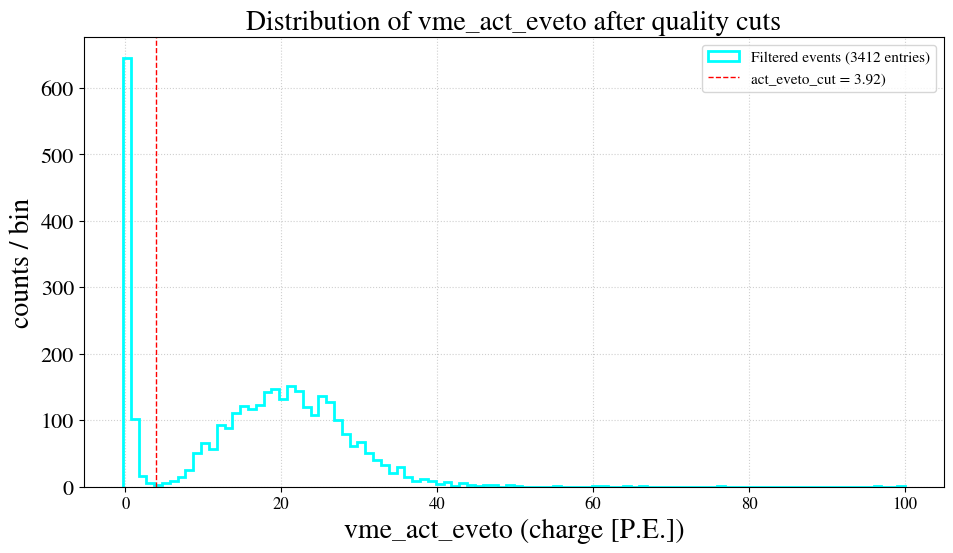

In [36]:
# extract the scalar constant cut value (index 0 since scalar tree has 1 entry per run)
eveto_cut_value = arrays_scalars["act_eveto_cut"][0]
eveto_data = filtered_windows["vme_act_eveto"]

plt.figure(figsize=(10, 6))

plt.hist(eveto_data, bins=100, histtype="step", linewidth=2, color="cyan", label=f"Filtered events ({len(eveto_data)} entries)")
plt.axvline(x=eveto_cut_value, color="red", linestyle="--", linewidth=1, label=f"act_eveto_cut = {eveto_cut_value:.2f})")

plt.title("Distribution of vme_act_eveto after quality cuts")
plt.xlabel("vme_act_eveto (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

Number of pions: 260


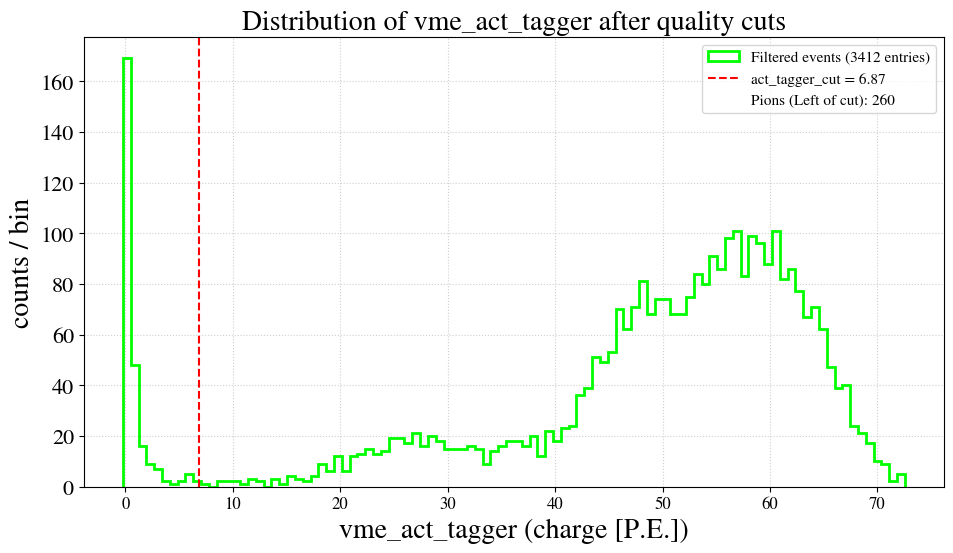

In [43]:
eveto_cut_value = arrays_scalars["act_tagger_cut"][0]
eveto_data = filtered_windows["vme_act_tagger"]

pion_mask = eveto_data < eveto_cut_value
n_pions = np.sum(pion_mask)  

print("Number of pions:", n_pions)

plt.figure(figsize=(10, 6))


plt.hist(eveto_data, bins=100, histtype="step", linewidth=2, color="lime", label=f"Filtered events ({len(eveto_data)} entries)")

plt.axvline(x=eveto_cut_value, color="red", linestyle="--", linewidth=1.5, label=f"act_tagger_cut = {eveto_cut_value:.2f}")


plt.title("Distribution of vme_act_tagger after quality cuts")
plt.xlabel("vme_act_tagger (charge [P.E.])")
plt.ylabel("counts / bin")
plt.grid(True, linestyle=":", alpha=0.6)


plt.plot([], [], ' ', label=f"Pions (Left of cut): {n_pions}")

plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()

In [44]:
n_pions = arrays_scalars["n_pions"]
print(n_pions)

[3009]
